In [1]:
# ==========================================================
# 🧹 Data Cleaning – Drop Unnecessary Columns (Actual Columns)
# ==========================================================
import pandas as pd

# --- Load CSVs ---
users_df   = pd.read_csv("dataset/users.csv")
hotels_df  = pd.read_csv("dataset/hotels.csv")
reviews_df = pd.read_csv("dataset/reviews.csv")

# --- Drop unneeded columns ---
users_drop_cols   = ["join_date"]  # optional
hotels_drop_cols  = ["hotel_name", "star_rating", "lat", "lon"]
reviews_drop_cols = ["review_text"]  # only if exists

users_df.drop(columns=users_drop_cols, errors='ignore', inplace=True)
hotels_df.drop(columns=hotels_drop_cols, errors='ignore', inplace=True)
reviews_df.drop(columns=reviews_drop_cols, errors='ignore', inplace=True)

# --- Show updated shapes ---
print(f"✅ Users dataframe shape after drop  : {users_df.shape}")
print(f"✅ Hotels dataframe shape after drop : {hotels_df.shape}")
print(f"✅ Reviews dataframe shape after drop: {reviews_df.shape}")

# --- Quick preview ---
display(users_df.head())
display(hotels_df.head())
display(reviews_df.head())


✅ Users dataframe shape after drop  : (2000, 5)
✅ Hotels dataframe shape after drop : (25, 9)
✅ Reviews dataframe shape after drop: (50000, 11)


,user_id,user_gender,country,age_group,traveller_type
0,1,Female,United Kingdom,35-44,Solo
1,2,Male,United Kingdom,25-34,Solo
2,3,Female,Mexico,25-34,Family
3,4,Male,India,35-44,Family
4,5,Other,Japan,25-34,Solo


,hotel_id,city,country,cleanliness_base,comfort_base,facilities_base,location_base,staff_base,value_for_money_base
0,1,New York,United States,9.1,8.8,8.9,9.5,8.6,8.0
1,2,London,United Kingdom,9.0,9.2,8.8,9.4,9.0,7.9
2,3,Paris,France,8.8,9.4,8.7,9.6,9.3,8.1
3,4,Tokyo,Japan,9.6,9.0,9.3,8.5,9.5,8.2
4,5,Dubai,United Arab Emirates,9.3,9.5,9.6,8.9,9.4,8.5


,review_id,user_id,hotel_id,review_date,score_overall,score_cleanliness,score_comfort,score_facilities,score_location,score_staff,score_value_for_money
0,1,1600,1,2022-10-07,8.7,8.6,8.7,8.5,9.0,8.8,8.7
1,2,432,4,2020-03-24,9.1,10.0,9.1,9.0,8.6,9.4,8.6
2,3,186,18,2023-12-18,8.8,9.7,8.8,8.3,8.7,8.1,8.6
3,4,1403,19,2022-06-22,8.9,9.0,8.8,8.5,9.6,9.1,8.3
4,5,1723,17,2022-07-02,9.1,8.9,9.5,9.3,8.3,9.4,8.9


In [2]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("dataset")

users   = pd.read_csv(DATA_DIR / "users.csv")
hotels  = pd.read_csv(DATA_DIR / "hotels.csv")
reviews = pd.read_csv(DATA_DIR / "reviews.csv")

print("Loaded -> users:", users.shape, "| hotels:", hotels.shape, "| reviews:", reviews.shape)

# ==========================================================
# ✅ Rename country columns BEFORE merging
# ==========================================================
users = users.rename(columns={"country": "user_country"})
hotels = hotels.rename(columns={"country": "hotel_country"})

# ==========================================================
# 🔗 Data Merging – Combine Users, Hotels, and Reviews
# ==========================================================

# --- Merge reviews with users on user_id ---
merged_df = pd.merge(reviews, users, on="user_id", how="left")

# --- Merge the result with hotels on hotel_id ---
merged_df = pd.merge(merged_df, hotels, on="hotel_id", how="left")

# --- Show shape and preview ---
print(f"✅ Final merged dataset shape: {merged_df.shape}")
display(merged_df.head())

# --- Optional sanity check ---
print("\nMissing values per column:")
print(merged_df.isnull().sum())

# --- Save merged dataset (for later use) ---
merged_df.to_csv("dataset/hotel_reviews_merged.csv", index=False)
print("\n💾 Merged dataset saved to: dataset/hotel_reviews_merged.csv")


Loaded -> users: (2000, 6) | hotels: (25, 13) | reviews: (50000, 12)
✅ Final merged dataset shape: (50000, 29)


,review_id,user_id,hotel_id,review_date,score_overall,score_cleanliness,score_comfort,score_facilities,score_location,score_staff,...,hotel_country,star_rating,lat,lon,cleanliness_base,comfort_base,facilities_base,location_base,staff_base,value_for_money_base
0,1,1600,1,2022-10-07,8.7,8.6,8.7,8.5,9.0,8.8,...,United States,5,40.7580,-73.9855,9.1,8.8,8.9,9.5,8.6,8.0
1,2,432,4,2020-03-24,9.1,10.0,9.1,9.0,8.6,9.4,...,Japan,5,35.6895,139.6917,9.6,9.0,9.3,8.5,9.5,8.2
2,3,186,18,2023-12-18,8.8,9.7,8.8,8.3,8.7,8.1,...,Egypt,5,30.0444,31.2357,8.8,8.7,8.6,9.1,8.7,8.4
3,4,1403,19,2022-06-22,8.9,9.0,8.8,8.5,9.6,9.1,...,Spain,5,41.3851,2.1734,9.2,9.1,8.9,9.7,9.0,8.8
4,5,1723,17,2022-07-02,9.1,8.9,9.5,9.3,8.3,9.4,...,Russia,5,55.7558,37.6173,9.1,9.3,9.0,9.0,9.1,8.6



Missing values per column:
review_id                0
user_id                  0
hotel_id                 0
review_date              0
score_overall            0
score_cleanliness        0
score_comfort            0
score_facilities         0
score_location           0
score_staff              0
score_value_for_money    0
review_text              0
user_gender              0
user_country             0
age_group                0
traveller_type           0
join_date                0
hotel_name               0
city                     0
hotel_country            0
star_rating              0
lat                      0
lon                      0
cleanliness_base         0
comfort_base             0
facilities_base          0
location_base            0
staff_base               0
value_for_money_base     0
dtype: int64

💾 Merged dataset saved to: dataset/hotel_reviews_merged.csv


C:\Users\mohan\AppData\Local\Temp\ipykernel_31520\837057835.py:70: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(agg_block)


,traveller_type,city,n,mean_composite,median_composite,std,ci95,mean_delta,total_n,min_n_type,rank
47,Business,Amsterdam,460.0,8.899565,8.900000,0.120082,0.010974,-0.311232,10371,104,1
34,Couple,Dubai,706.0,9.050121,9.057143,0.115456,0.008517,-0.156067,17240,173,1
72,Family,Dubai,452.0,9.194817,9.200000,0.118566,0.010931,-0.008444,11945,120,1
82,Solo,Dubai,443.0,9.091938,9.085714,0.117770,0.010967,-0.109481,10444,105,1


,traveller_type,city,n,mean_composite,median_composite,std,ci95,mean_delta,total_n,min_n_type,rank
47,Business,Amsterdam,460.0,8.899565,8.900000,0.120082,0.010974,-0.311232,10371,104,1
38,Business,Dubai,434.0,8.892758,8.900000,0.122072,0.011485,-0.319393,10371,104,2
7,Business,Singapore,407.0,8.852018,8.842857,0.119745,0.011634,-0.296724,10371,104,3
34,Couple,Dubai,706.0,9.050121,9.057143,0.115456,0.008517,-0.156067,17240,173,1
43,Couple,Amsterdam,631.0,9.049808,9.057143,0.116647,0.009102,-0.158056,17240,173,2
15,Couple,Singapore,700.0,9.006694,9.000000,0.120598,0.008934,-0.133452,17240,173,3
72,Family,Dubai,452.0,9.194817,9.200000,0.118566,0.010931,-0.008444,11945,120,1
67,Family,Amsterdam,444.0,9.186937,9.185714,0.117887,0.010966,-0.014602,11945,120,2
17,Family,Shanghai,481.0,9.152094,9.157143,0.118217,0.010565,0.017256,11945,120,3
82,Solo,Dubai,443.0,9.091938,9.085714,0.117770,0.010967,-0.109481,10444,105,1


💾 Saved: dataset/out_best_city_per_traveller_type.csv
💾 Saved: dataset/out_top3_cities_per_traveller_type.csv
💾 Saved: dataset/out_all_city_stats.csv


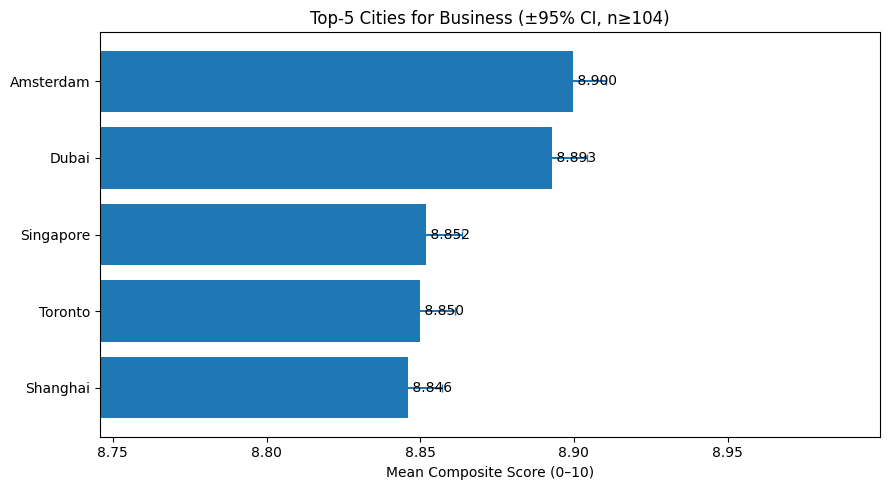

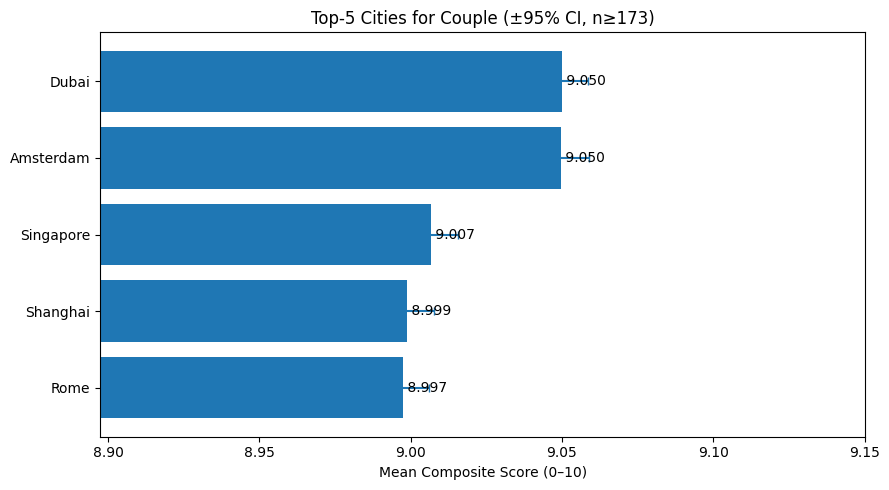

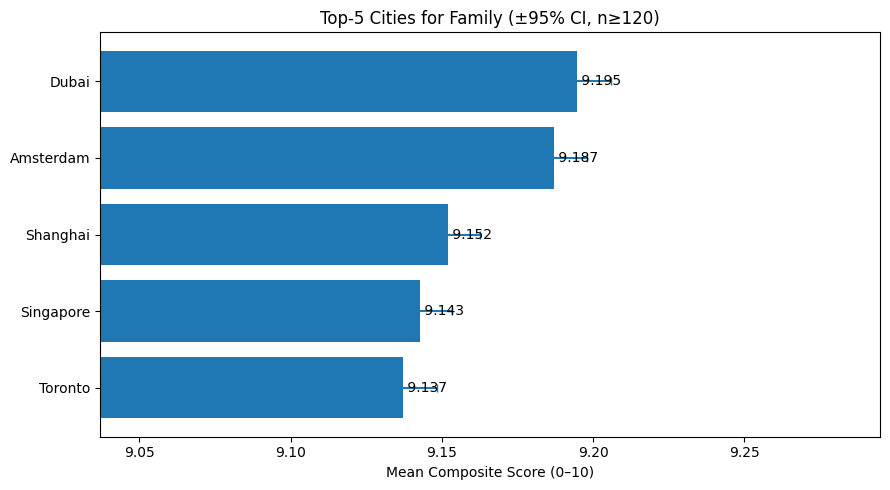

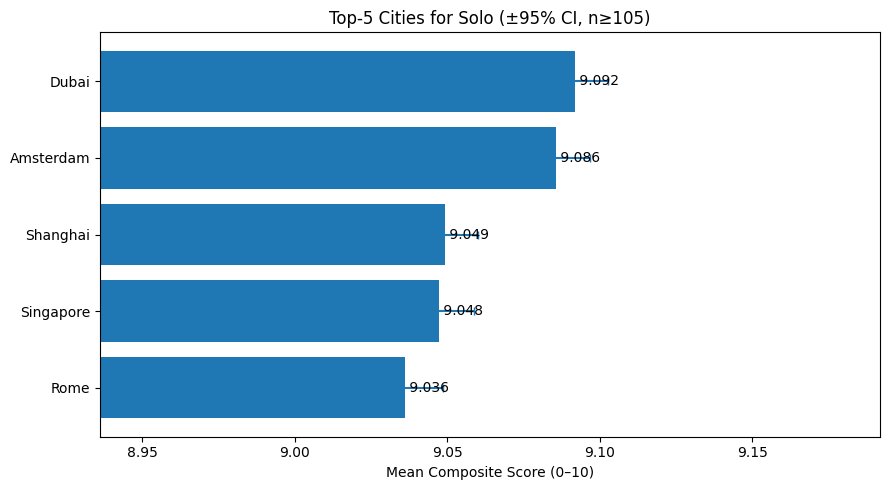

🖼️ Saved charts:
   - dataset/plot_top5_business.png
   - dataset/plot_top5_couple.png
   - dataset/plot_top5_family.png
   - dataset/plot_top5_solo.png
🖼️ Saved chart: dataset/plot_winners_summary.png


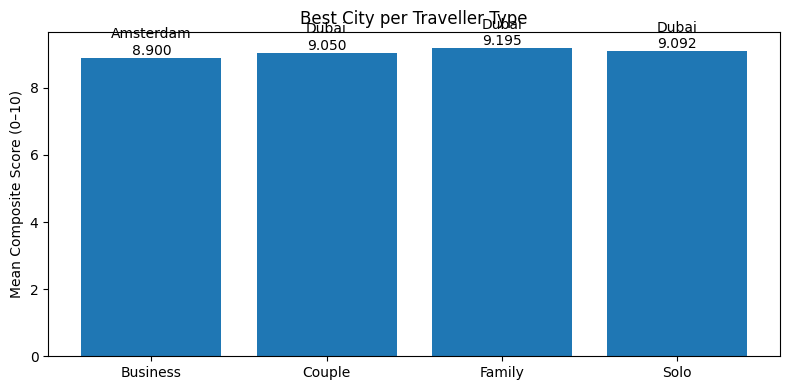

In [3]:
# ==========================================================
# Which city is best for each traveller_type?
# End-to-end: load → prep → aggregate → rank → visualize → save
# ==========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt, ceil

# ---------- 1) Load & tidy ----------
DATA_PATH = "dataset/hotel_reviews_merged.csv"
df = pd.read_csv(DATA_PATH)

# explicit names
df = df.rename(columns={"country_y": "user_country", "country_x": "hotel_country"})
df["review_date"] = pd.to_datetime(df["review_date"], errors="coerce")

score_cols = [
    "score_overall","score_cleanliness","score_comfort","score_facilities",
    "score_location","score_staff","score_value_for_money"
]
base_cols = [
    "cleanliness_base","comfort_base","facilities_base",
    "location_base","staff_base","value_for_money_base"
]

# keep only rows we can use
df = df.dropna(subset=["traveller_type","city"])
# defensive: clip scores to [0,10]
for c in score_cols:
    if c in df.columns:
        df[c] = df[c].clip(0, 10)

# ---------- 2) Metrics ----------
# Composite 0..10
df["composite"] = df[score_cols].mean(axis=1)

# Delta vs hotel baselines (how much reviews beat/lag the hotel's base)
df["delta_mean"] = (
    pd.concat([
        df["score_cleanliness"]     - df["cleanliness_base"],
        df["score_comfort"]         - df["comfort_base"],
        df["score_facilities"]      - df["facilities_base"],
        df["score_location"]        - df["location_base"],
        df["score_staff"]           - df["staff_base"],
        df["score_value_for_money"] - df["value_for_money_base"],
    ], axis=1)
    .mean(axis=1)
)

# ---------- 3) Aggregate per (traveller_type, city) ----------
def agg_block(g: pd.DataFrame) -> pd.Series:
    n   = g.shape[0]
    m   = g["composite"].mean()
    med = g["composite"].median()
    sd  = g["composite"].std(ddof=1)
    ci  = 1.96 * (sd / sqrt(n)) if n >= 30 and pd.notna(sd) else np.nan  # normal approx
    m_delta = g["delta_mean"].mean()
    return pd.Series({
        "n": n,
        "mean_composite": m,
        "median_composite": med,
        "std": sd,
        "ci95": ci,
        "mean_delta": m_delta
    })

agg = (
    df.groupby(["traveller_type","city"], as_index=False, sort=False)
      .apply(agg_block)
      .reset_index(drop=True)
)

# ---------- 4) Minimum sample size (per-type) ----------
# auto-tune: at least 30, or 1% of that traveller_type's total reviews (whichever is larger)
type_counts = df.groupby("traveller_type").size().rename("total_n")
agg = agg.merge(type_counts, on="traveller_type", how="left")
agg["min_n_type"] = (agg["total_n"] * 0.01).apply(lambda x: max(30, int(ceil(x))))
agg = agg[agg["n"] >= agg["min_n_type"]].copy()

# ---------- 5) Rank within traveller_type ----------
# Tie-breakers: mean desc, n desc, median desc, city asc (deterministic)
agg = agg.sort_values(
    ["traveller_type","mean_composite","n","median_composite","city"],
    ascending=[True, False, False, False, True]
)
agg["rank"] = agg.groupby("traveller_type").cumcount() + 1

winners = agg[agg["rank"] == 1].copy()
top3    = agg[agg["rank"] <= 3].copy()

# Show in notebook
display(winners.sort_values("traveller_type"))
display(top3.sort_values(["traveller_type","rank","city"]))

# Save tabular outputs
winners_path = "dataset/out_best_city_per_traveller_type.csv"
top3_path    = "dataset/out_top3_cities_per_traveller_type.csv"
agg_path     = "dataset/out_all_city_stats.csv"

winners.to_csv(winners_path, index=False)
top3.to_csv(top3_path, index=False)
agg.drop(columns=["total_n","min_n_type"]).to_csv(agg_path, index=False)

print(f"💾 Saved: {winners_path}")
print(f"💾 Saved: {top3_path}")
print(f"💾 Saved: {agg_path}")

# ---------- 6) Visuals ----------
# Top-5 per traveller_type (bars with CI labels)
top5 = (
    agg.sort_values(["traveller_type","mean_composite","n"], ascending=[True, False, False])
       .groupby("traveller_type")
       .head(5)
)

plot_paths = []
for ttype, sub in top5.groupby("traveller_type"):
    sub = sub.sort_values("mean_composite", ascending=True)
    y = np.arange(len(sub))

    plt.figure(figsize=(9, 5))
    bars = plt.barh(y, sub["mean_composite"])  # default color, no style
    # CI bars if available
    if sub["ci95"].notna().any():
        plt.errorbar(sub["mean_composite"], y, xerr=sub["ci95"].fillna(0), fmt='none', capsize=3)

    # annotate values
    for i, v in enumerate(sub["mean_composite"]):
        plt.text(v, i, f" {v:.3f}", va="center")

    # zoom x-range to useful window
    lo = max(0, sub["mean_composite"].min() - 0.1)
    hi = min(10, sub["mean_composite"].max() + 0.1)
    plt.xlim(lo, hi)

    plt.yticks(y, sub["city"])
    plt.xlabel("Mean Composite Score (0–10)")
    min_n = int(sub["min_n_type"].iloc[0])
    plt.title(f"Top-5 Cities for {ttype} (±95% CI, n≥{min_n})")
    plt.tight_layout()

    out_png = f"dataset/plot_top5_{ttype.replace(' ','_').lower()}.png"
    plt.savefig(out_png, dpi=150)
    plot_paths.append(out_png)
    plt.show()

print("🖼️ Saved charts:")
for p in plot_paths:
    print("   -", p)

# ---------- 7) Winners summary chart (one bar per traveller_type) ----------
# Useful for the report: shows best city per type side-by-side.
win_plot = winners.sort_values("traveller_type").copy()
plt.figure(figsize=(8, 4))
x = np.arange(win_plot.shape[0])
plt.bar(x, win_plot["mean_composite"])
for i, (city, val) in enumerate(zip(win_plot["city"], win_plot["mean_composite"])):
    plt.text(i, val, f"{city}\n{val:.3f}", ha="center", va="bottom")

plt.xticks(x, win_plot["traveller_type"], rotation=0)
plt.ylabel("Mean Composite Score (0–10)")
plt.title("Best City per Traveller Type")
plt.tight_layout()
out_png = "dataset/plot_winners_summary.png"
plt.savefig(out_png, dpi=150)
print("🖼️ Saved chart:", out_png)
plt.show()


✅ Top-3 countries by Median Value-for-Money per age group:


,age_group,hotel_country,n,median_vfm
0,18-24,China,231,8.80
1,18-24,Netherlands,224,8.75
2,18-24,Canada,222,8.70
3,25-34,China,680,8.80
4,25-34,Spain,674,8.70
5,25-34,New Zealand,659,8.70
6,35-44,Netherlands,609,8.80
7,35-44,New Zealand,672,8.70
8,35-44,Canada,645,8.70
9,45-54,China,303,8.80


💾 Saved: dataset/out_top3_vfm_countries_per_agegroup.csv
💾 Saved: dataset/out_all_vfm_country_stats.csv


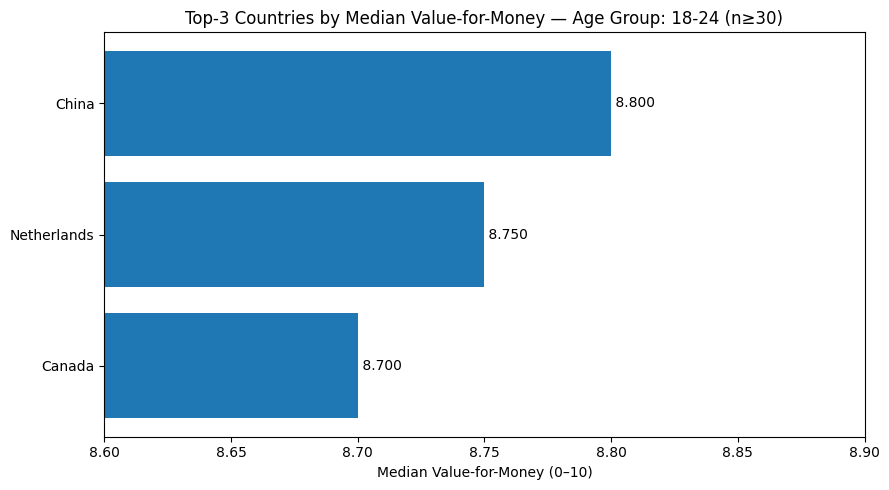

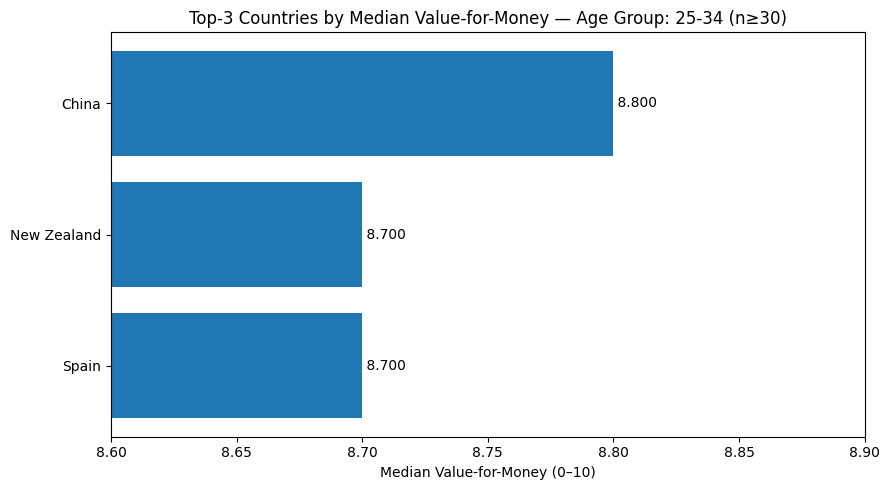

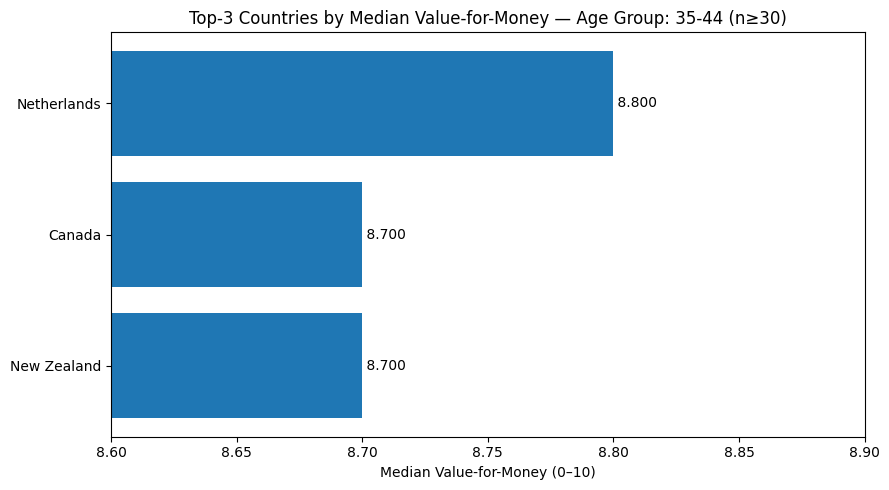

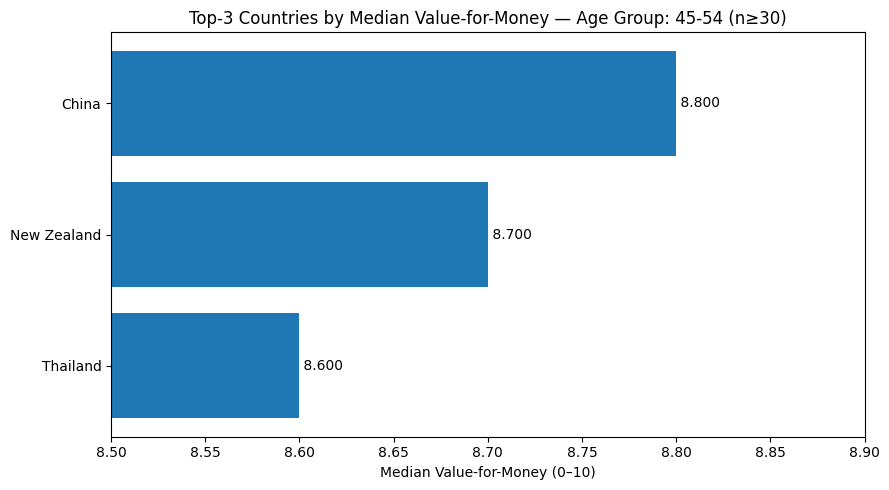

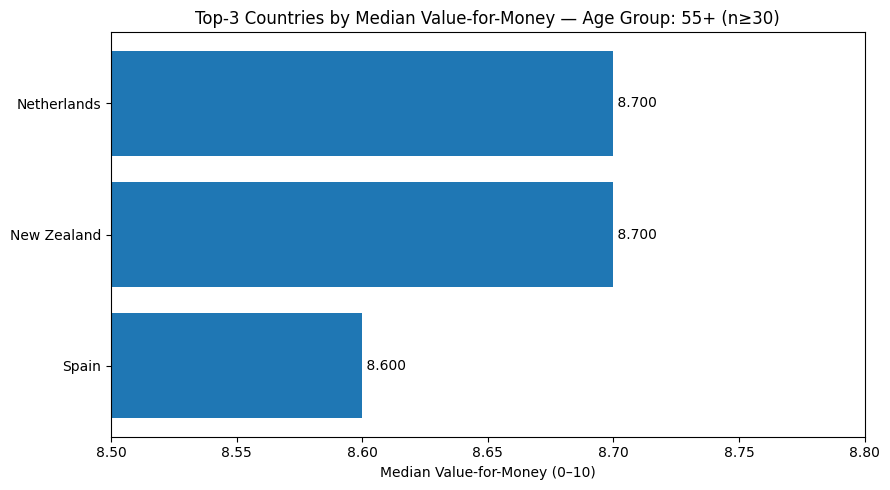

In [4]:
# ================================================
# TOP-3 COUNTRIES BY VALUE-FOR-MONEY PER AGE GROUP
# (Ranked by MEDIAN; keep only: age_group, hotel_country, n, median_vfm)
# ================================================

import pandas as pd
import numpy as np

# 1) Load
DATA_PATH = "dataset/hotel_reviews_merged.csv"
df = pd.read_csv(DATA_PATH)

# 2) Clear column names
df = df.rename(columns={"country_x": "user_country", "country_y": "hotel_country"})

# 3) Keep only what's needed
NEEDED = ["age_group", "hotel_country", "score_value_for_money"]
missing = [c for c in NEEDED if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

df = df.dropna(subset=NEEDED).copy()
df["score_value_for_money"] = df["score_value_for_money"].clip(0, 10)

# 4) Aggregate per (age_group, hotel_country)
agg = (
    df.groupby(["age_group", "hotel_country"], as_index=False)
      .agg(
          n=("score_value_for_money", "size"),
          median_vfm=("score_value_for_money", "median"),
      )
)

# 5) Filter out tiny groups (noisy)
MIN_N = 30
agg = agg[agg["n"] >= MIN_N].copy()

# 6) Rank within each age group by MEDIAN (then n as tiebreaker)
agg = agg.sort_values(
    ["age_group", "median_vfm", "n", "hotel_country"],
    ascending=[True, False, False, True]
)
agg["rank"] = agg.groupby("age_group").cumcount() + 1

# 7) Take Top-3 and keep only requested columns
top3 = (
    agg[agg["rank"] <= 3][["age_group", "hotel_country", "n", "median_vfm"]]
      .sort_values(["age_group", "median_vfm", "n", "hotel_country"],
                   ascending=[True, False, False, True])
      .reset_index(drop=True)
)

print("✅ Top-3 countries by Median Value-for-Money per age group:")
display(top3)

# (Optional) Save
top3.to_csv("dataset/out_top3_vfm_countries_per_agegroup.csv", index=False)


# 8) SHOW AND SAVE RESULTS (keep only requested columns)
COLS = ["age_group", "hotel_country", "n", "median_vfm"]

top3_slim = (
    top3[COLS]
    .sort_values(["age_group", "median_vfm", "n", "hotel_country"],
                 ascending=[True, False, False, True])
    .reset_index(drop=True)
)



# Save trimmed Top-3
top3_path = "dataset/out_top3_vfm_countries_per_agegroup.csv"
top3_slim.to_csv(top3_path, index=False)
print(f"💾 Saved: {top3_path}")

# (Optional) Save the full stats table too (unchanged)
all_path = "dataset/out_all_vfm_country_stats.csv"
agg.to_csv(all_path, index=False)
print(f"💾 Saved: {all_path}")



# 9) BAR CHARTS: Top-3 only per age group (using median_vfm)
for age, sub in top3_slim.groupby("age_group"):
    sub = sub.sort_values("median_vfm", ascending=True)
    y = np.arange(len(sub))

    plt.figure(figsize=(9, 5))
    plt.barh(y, sub["median_vfm"])
    plt.yticks(y, sub["hotel_country"])
    plt.xlabel("Median Value-for-Money (0–10)")
    plt.title(f"Top-3 Countries by Median Value-for-Money — Age Group: {age} (n≥{MIN_N})")

    for i, val in enumerate(sub["median_vfm"]):
        plt.text(val, i, f" {val:.3f}", va="center")

    lo = max(0, sub["median_vfm"].min() - 0.1)
    hi = min(10, sub["median_vfm"].max() + 0.1)
    plt.xlim(lo, hi)

    plt.tight_layout()
    plt.show()


In [5]:
df = pd.read_csv("dataset/hotel_reviews_merged.csv")
country_group_mapping = {
    "United States": "North_America",
    "Canada": "North_America",
    "Germany": "Western_Europe",
    "France": "Western_Europe",
    "United Kingdom": "Western_Europe",
    "Netherlands": "Western_Europe",
    "Spain": "Western_Europe",
    "Italy": "Western_Europe",
    "Russia": "Eastern_Europe",
    "China": "East_Asia",
    "Japan": "East_Asia",
    "South Korea": "East_Asia",
    "Thailand": "Southeast_Asia",
    "Singapore": "Southeast_Asia",
    "United Arab Emirates": "Middle_East",
    "Turkey": "Middle_East",
    "Egypt": "Africa",
    "Nigeria": "Africa",
    "South Africa": "Africa",
    "Australia": "Oceania",
    "New Zealand": "Oceania",
    "Brazil": "South_America",
    "Argentina": "South_America",
    "India": "South_Asia",
    "Mexico": "North_America_Mexico"
}

# Create the new column
df["country_group"] = df["hotel_country"].map(country_group_mapping)
df.to_csv("dataset/hotel_reviews_merged_country_groups.csv", index=False)

In [6]:
df = pd.read_csv("dataset/hotel_reviews_merged_country_groups.csv")

# Define selected columns
selected_features = [
    "country_group",  # Make sure this column exists or is created before saving
    "score_overall", "score_cleanliness", "score_comfort", "score_facilities", "score_location","user_country",
    "score_staff", "score_value_for_money", "user_gender", "age_group", "traveller_type",
   "cleanliness_base", "comfort_base", "facilities_base", "location_base",
    "staff_base", "value_for_money_base"
]

# Keep only those columns that exist in the dataframe (avoid errors)
existing_features = [col for col in selected_features if col in df.columns]
numerical_features = ["score_overall", "score_cleanliness", "score_comfort", "score_facilities", "score_location", "score_staff", "score_value_for_money","cleanliness_base", "comfort_base", "facilities_base", "location_base",
    "staff_base", "value_for_money_base"]
categorical_features = ["user_gender", "age_group", "traveller_type"]
# Create new dataframe
filtered_df = df[existing_features]

# Save it to a new CSV file
output_path = "dataset/predict_country_groups.csv"
filtered_df.to_csv(output_path, index=False)

print(f"✅ File saved successfully at: {output_path}")
print("Included columns:", existing_features)

✅ File saved successfully at: dataset/predict_country_groups.csv
Included columns: ['country_group', 'score_overall', 'score_cleanliness', 'score_comfort', 'score_facilities', 'score_location', 'user_country', 'score_staff', 'score_value_for_money', 'user_gender', 'age_group', 'traveller_type', 'cleanliness_base', 'comfort_base', 'facilities_base', 'location_base', 'staff_base', 'value_for_money_base']


In [7]:
import pandas as pd

# Load the CSV
df = pd.read_csv("dataset/predict_country_groups.csv")

# List of categorical features to one-hot encode
categorical_features = ["age_group", "traveller_type","user_country"]

# One-hot encode and replace
df['user_gender'] = df['user_gender'].map({'Male': 0, 'Female': 1})

df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=True)


# Save the encoded DataFrame
df_encoded.to_csv("dataset/predict_country_groups_encoded.csv", index=False)

print("✅ One-hot encoding complete. Saved as predict_country_groups_encoded.csv")


✅ One-hot encoding complete. Saved as predict_country_groups_encoded.csv


In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

# ==========================================================
# 1️⃣ Load and Prepare Data
# ==========================================================
df = pd.read_csv("dataset/predict_country_groups_encoded.csv")

# Drop rows where country_group is missing
df = df.dropna(subset=["country_group"])

# --- Select features (X) and target (y) ---
# Example: You can pick any columns that might be relevant
# (remove text or ID columns)
X = df.drop(columns=["country_group"], errors='ignore')
leakage_cols = [col for col in X.columns if  "cleanliness_base" in col.lower() or "comfort_base" in col.lower() or "staff_base" in col.lower() or "facilities_base" in col.lower() or "value_for_money_base" in col.lower()]
X = X.drop(columns=leakage_cols)
print(X.columns)
y = df["country_group"]
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# ==========================================================
# 2️⃣ Train/Test Split
# ==========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)


# ==========================================================
# 3️⃣ Feature Scaling
# ==========================================================

# ==========================================================
# 4️⃣ Train a Model (Random Forest)
# ==========================================================
model = RandomForestClassifier(n_estimators=1004, random_state=125)
model.fit(X_train, y_train)

importances = model.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({"feature": feature_names, "importance": importances})
importance_df = importance_df.sort_values(by="importance", ascending=False)

print(importance_df)
# ==========================================================
# 5️⃣ Evaluate
# ==========================================================
y_pred = model.predict(X_test)

print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("\n🔍 Classification Report:")
print(classification_report(y_test, y_pred))

print("\n🧩 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Index(['score_overall', 'score_cleanliness', 'score_comfort',
       'score_facilities', 'score_location', 'score_staff',
       'score_value_for_money', 'user_gender', 'location_base',
       'age_group_25-34', 'age_group_35-44', 'age_group_45-54',
       'age_group_55+', 'traveller_type_Couple', 'traveller_type_Family',
       'traveller_type_Solo', 'user_country_Australia', 'user_country_Brazil',
       'user_country_Canada', 'user_country_China', 'user_country_Egypt',
       'user_country_France', 'user_country_Germany', 'user_country_India',
       'user_country_Italy', 'user_country_Japan', 'user_country_Mexico',
       'user_country_Netherlands', 'user_country_New Zealand',
       'user_country_Nigeria', 'user_country_Russia', 'user_country_Singapore',
       'user_country_South Africa', 'user_country_South Korea',
       'user_country_Spain', 'user_country_Thailand', 'user_country_Turkey',
       'user_country_United Arab Emirates', 'user_country_United Kingdom',
       'user_c

In [9]:
low_importance_features = importance_df[importance_df["importance"] < 0.005]["feature"]
X = X.drop(columns=low_importance_features)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("\n🔍 Classification Report:")
print(classification_report(y_test, y_pred))

print("\n🧩 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


✅ Accuracy: 0.7711

🔍 Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.84      1226
           1       0.80      0.71      0.75      1216
           2       0.52      0.49      0.51       394
           3       0.83      0.79      0.81       797
           4       0.85      0.85      0.85       792
           5       0.64      0.67      0.65       401
           6       0.69      0.66      0.68       803
           7       0.61      0.57      0.59       784
           8       0.99      0.95      0.97       398
           9       0.85      0.68      0.76       814
          10       0.76      0.89      0.82      2375

    accuracy                           0.77     10000
   macro avg       0.76      0.74      0.75     10000
weighted avg       0.77      0.77      0.77     10000


🧩 Confusion Matrix:
[[1055   13    0    0   47    0    0   55    1    3   52]
 [  22  865    0  116    0    0    0    0    0    0  213]
 [   

In [10]:
print(df.groupby("country_group")[["score_overall","score_location","score_staff"]].mean())


                      score_overall  score_location  score_staff
country_group                                                   
Africa                     8.808871        9.090753     8.844814
East_Asia                  9.012808        8.990497     9.149770
Eastern_Europe             8.966954        8.994772     9.034619
Middle_East                9.004996        9.061235     9.070675
North_America              8.934553        9.094725     8.888718
North_America_Mexico       8.759381        8.991866     8.763323
Oceania                    8.960289        9.261360     8.957275
South_America              8.845840        9.162864     8.822563
South_Asia                 8.841227        9.130970     8.817798
Southeast_Asia             9.029828        9.366118     9.040197
Western_Europe             9.000977        9.361351     9.023198


In [11]:
%pip install shap lime --quiet

Note: you may need to restart the kernel to use updated packages.


In [12]:
%pip install tqdm --quiet

Note: you may need to restart the kernel to use updated packages.


100%|===================| 1096/1100 [01:37<00:00]        

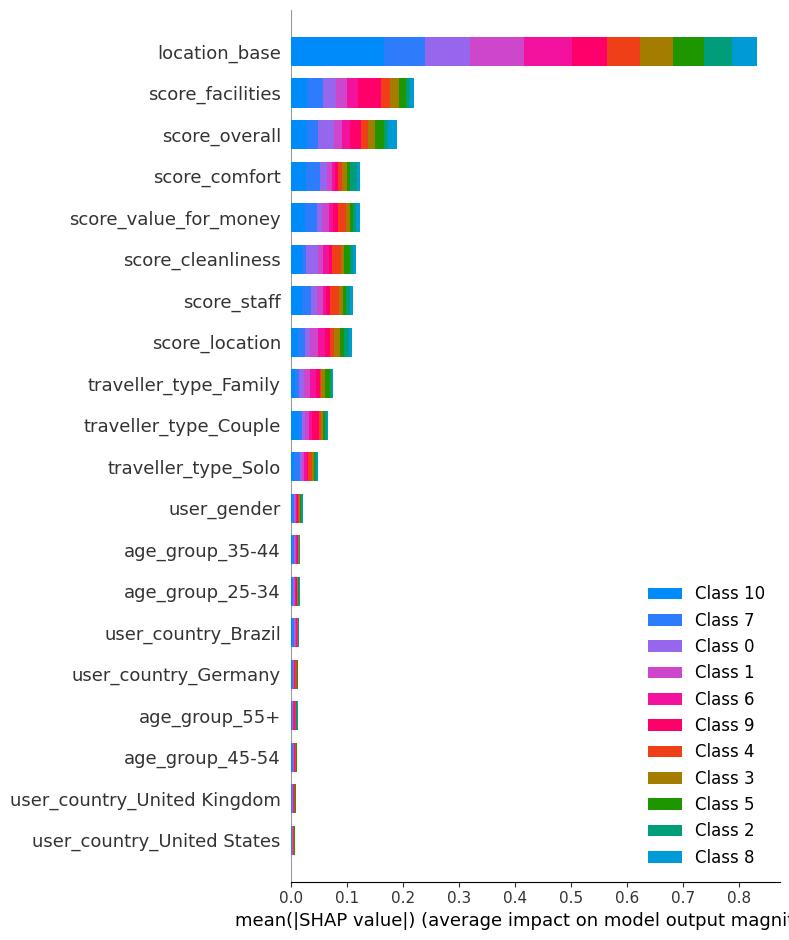

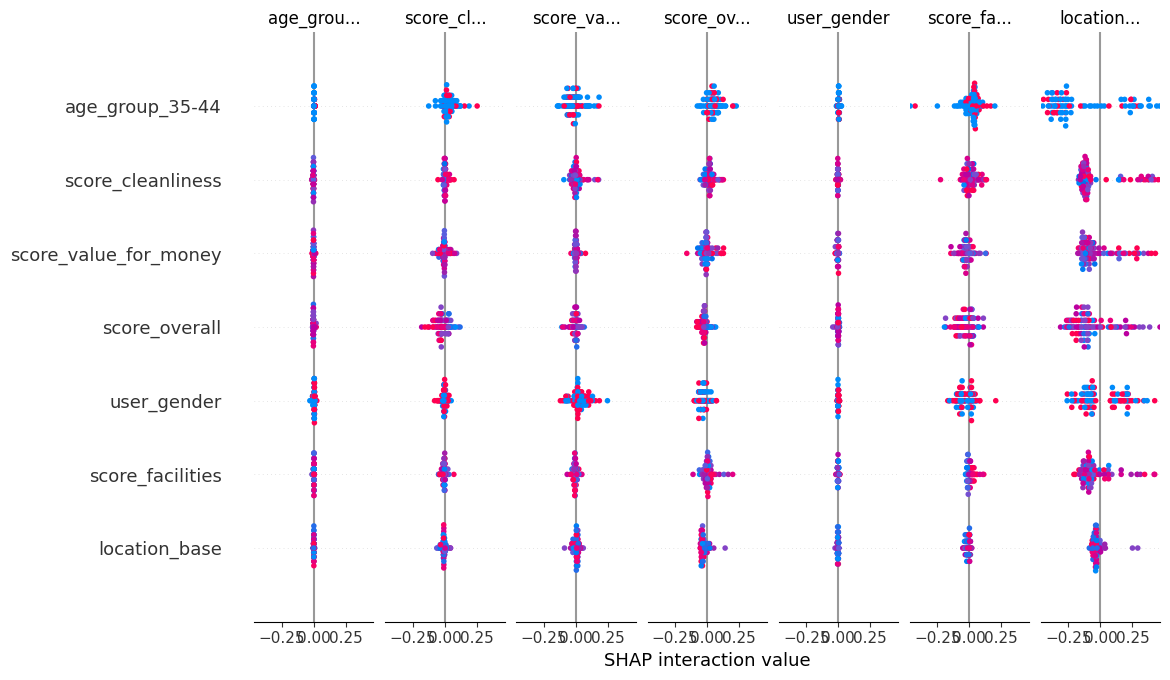

In [34]:
import shap

# 1) Sample
X_test_sample = shap.sample(X_test_fix, 100, random_state=42)
background     = shap.sample(X_train_fix, 20,  random_state=42)

# 2) Explainer (tree models)
explainer = shap.TreeExplainer(
    model,
    background,
    feature_perturbation="interventional"   # robust + fast
)

# 3) SHAP values (skip additivity check for speed)
shap_values = explainer.shap_values(X_test_sample, check_additivity=False)

# 4) Plots
shap.summary_plot(shap_values, X_test_sample, plot_type="bar")
shap.summary_plot(shap_values, X_test_sample)


🔍 Explaining row 5009 | Predicted class: South_Asia



,Country Group,Probability
0,South_Asia,0.540
1,Africa,0.200
2,Western_Europe,0.085
3,South_America,0.080
4,Middle_East,0.075
5,North_America_Mexico,0.010
6,Oceania,0.005
7,Southeast_Asia,0.005
8,East_Asia,0.000
9,Eastern_Europe,0.000


<Figure size 640x480 with 0 Axes>

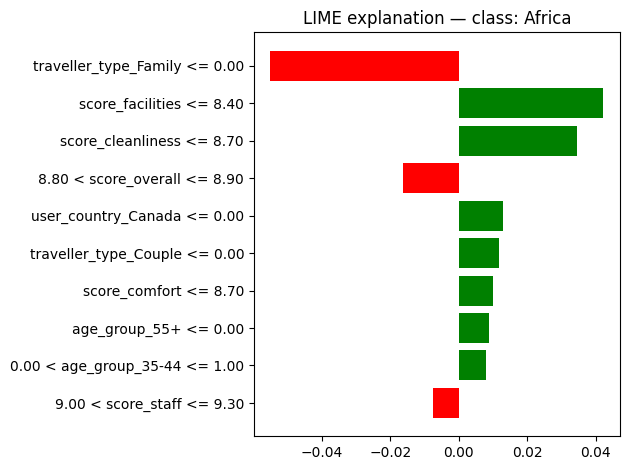

<Figure size 640x480 with 0 Axes>

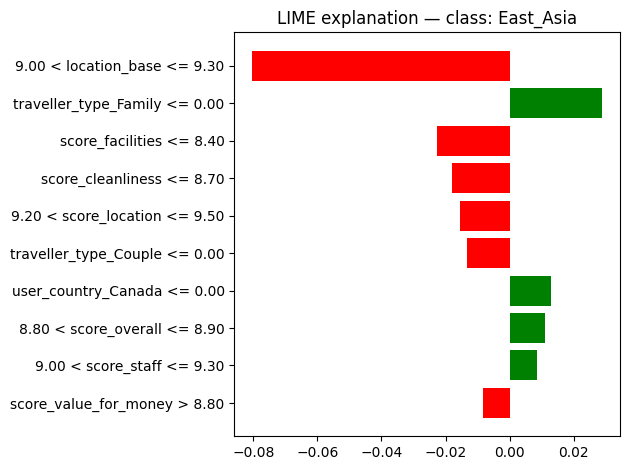

<Figure size 640x480 with 0 Axes>

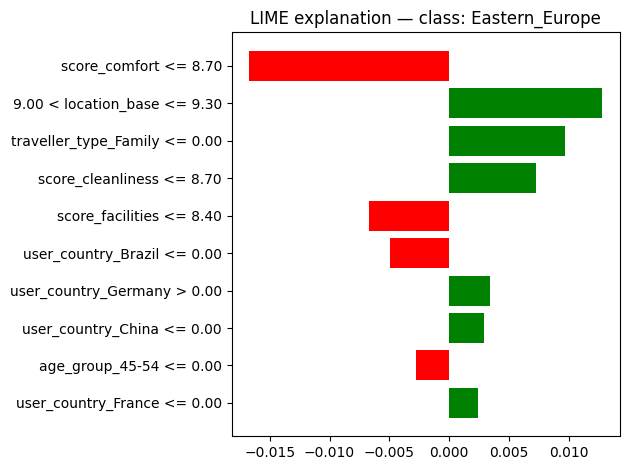

<Figure size 640x480 with 0 Axes>

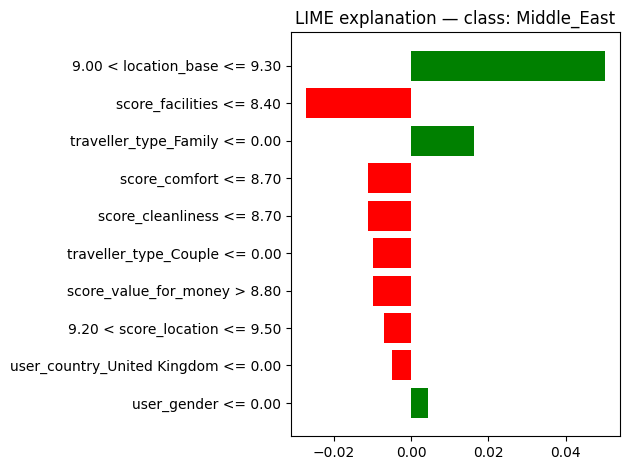

<Figure size 640x480 with 0 Axes>

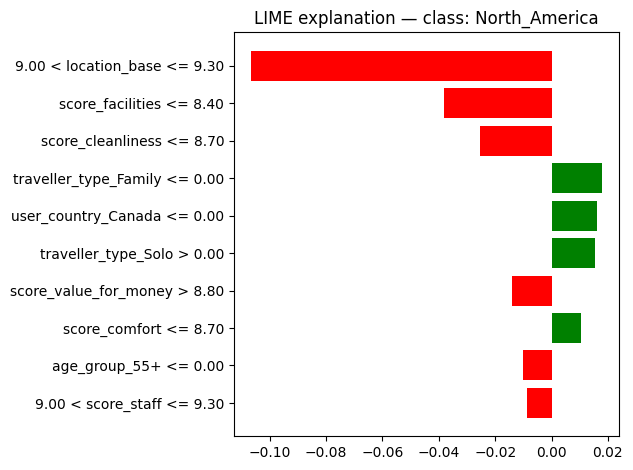

<Figure size 640x480 with 0 Axes>

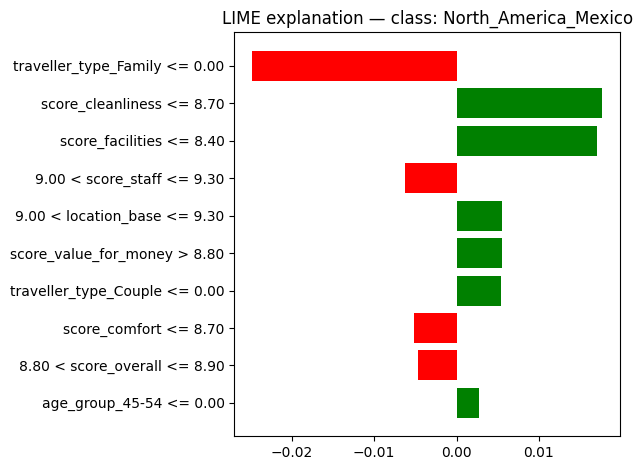

<Figure size 640x480 with 0 Axes>

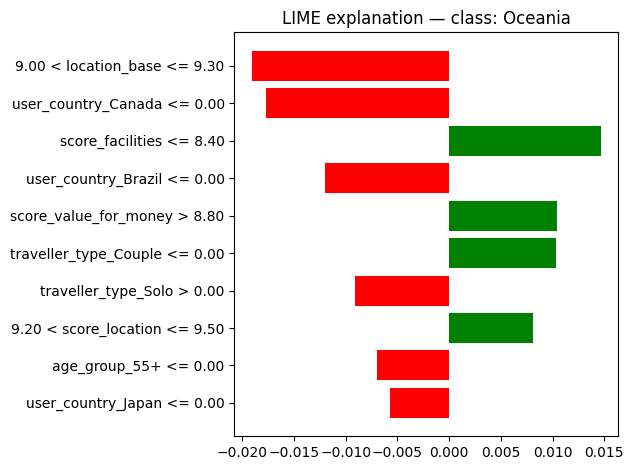

<Figure size 640x480 with 0 Axes>

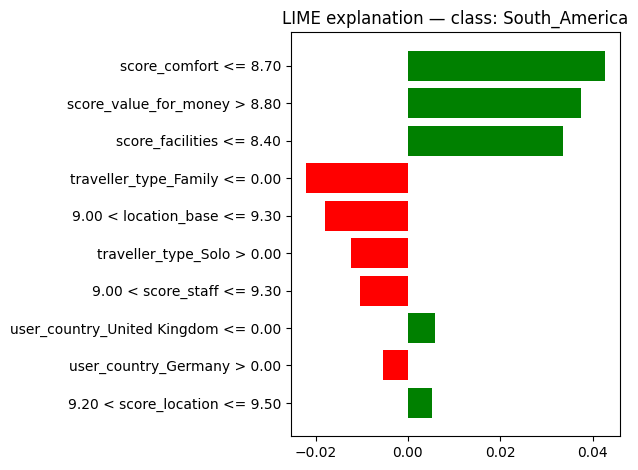

<Figure size 640x480 with 0 Axes>

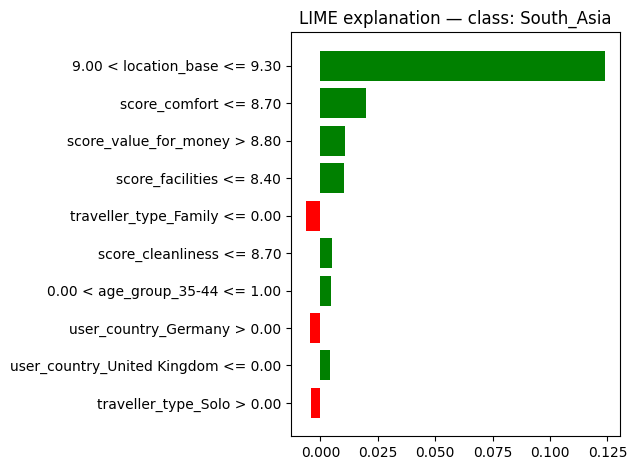

<Figure size 640x480 with 0 Axes>

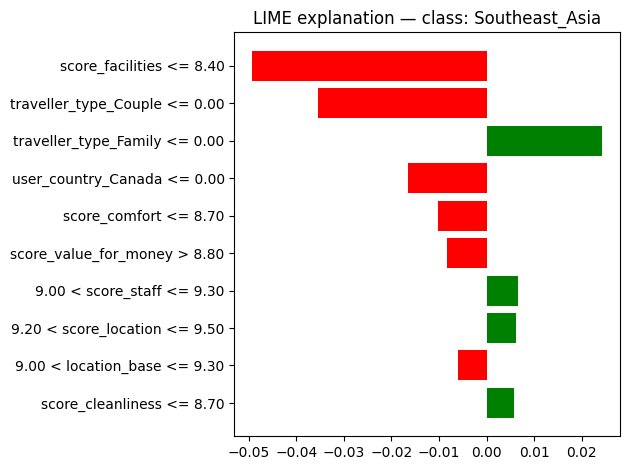

<Figure size 640x480 with 0 Axes>

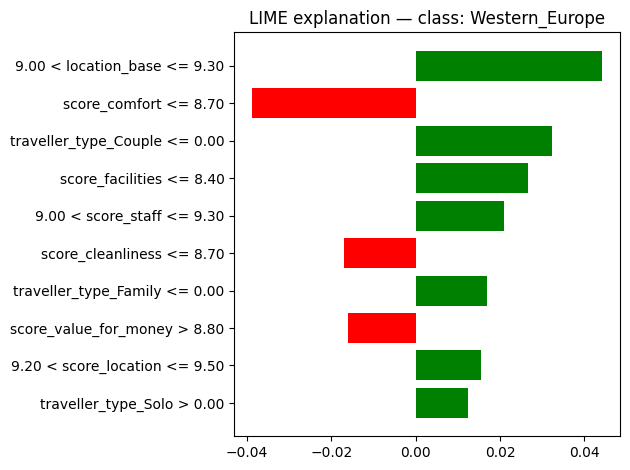


=== Africa ===
      traveller_type_Family <= 0.00 : -0.0550 (↓)
           score_facilities <= 8.40 : +0.0422 (↑)
          score_cleanliness <= 8.70 : +0.0344 (↑)
       8.80 < score_overall <= 8.90 : -0.0163 (↓)
        user_country_Canada <= 0.00 : +0.0128 (↑)
      traveller_type_Couple <= 0.00 : +0.0116 (↑)
              score_comfort <= 8.70 : +0.0100 (↑)
              age_group_55+ <= 0.00 : +0.0090 (↑)
     0.00 < age_group_35-44 <= 1.00 : +0.0080 (↑)
         9.00 < score_staff <= 9.30 : -0.0075 (↓)

=== East_Asia ===
       9.00 < location_base <= 9.30 : -0.0804 (↓)
      traveller_type_Family <= 0.00 : +0.0290 (↑)
           score_facilities <= 8.40 : -0.0227 (↓)
          score_cleanliness <= 8.70 : -0.0179 (↓)
      9.20 < score_location <= 9.50 : -0.0153 (↓)
      traveller_type_Couple <= 0.00 : -0.0134 (↓)
        user_country_Canada <= 0.00 : +0.0130 (↑)
       8.80 < score_overall <= 8.90 : +0.0111 (↑)
         9.00 < score_staff <= 9.30 : +0.0085 (↑)
       score_va

In [29]:
# === LIME multi-class explanation with probability table & visuals ===

# %pip install lime -q  # uncomment if needed

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML, display
from lime.lime_tabular import LimeTabularExplainer

# 1️⃣ Choose cleaned data if available
X_train_lime = X_train_fix if 'X_train_fix' in globals() else X_train
X_test_lime  = X_test_fix  if 'X_test_fix'  in globals() else X_test

# Keep same column order as model
if hasattr(model, "feature_names_in_"):
    X_train_lime = X_train_lime[model.feature_names_in_]
    X_test_lime  = X_test_lime[model.feature_names_in_]

feature_names = list(X_train_lime.columns)

# 2️⃣ Class names
if 'le' in globals():
    class_names = [str(c) for c in le.classes_]
elif hasattr(model, "classes_"):
    class_names = [str(c) for c in model.classes_]
else:
    class_names = [str(i) for i in range(len(np.unique(y_train)))]

# 3️⃣ Build LIME explainer
explainer_lime = LimeTabularExplainer(
    training_data=X_train_lime.values,
    feature_names=feature_names,
    class_names=class_names,
    mode="classification",
    discretize_continuous=True,
    sample_around_instance=True,
    random_state=42
)

# 4️⃣ Prediction function
def predict_fn_lime(data_2d):
    df = pd.DataFrame(data_2d, columns=feature_names)
    if hasattr(model, "feature_names_in_"):
        df = df[model.feature_names_in_]
    return model.predict_proba(df)

# 5️⃣ Pick a test row to explain
i = 5009
x_i = X_test_lime.iloc[i].values
proba_i = model.predict_proba(X_test_lime.iloc[[i]])[0]
pred_idx = int(np.argmax(proba_i))
pred_label = class_names[pred_idx]

# ---- Probability Table ----
proba_df = pd.DataFrame({
    "Country Group": class_names,
    "Probability": proba_i
}).sort_values("Probability", ascending=False).reset_index(drop=True)

print(f"🔍 Explaining row {i} | Predicted class: {pred_label}\n")
display(HTML(proba_df.style
             .background_gradient(cmap="Blues", subset=["Probability"])
             .format({"Probability": "{:.3f}"})
             .set_caption("Model Prediction Probabilities")
             .to_html()))

# 6️⃣ Generate LIME explanation for ALL classes
exp = explainer_lime.explain_instance(
    data_row=x_i,
    predict_fn=predict_fn_lime,
    num_features=10,
    top_labels=len(class_names),   # explain all country groups
    num_samples=5000
)

# 7️⃣ Show interactive HTML (LIME’s built-in visualization)
display(HTML(exp.as_html()))

# 8️⃣ Bar plots for each country group (one per class)
%matplotlib inline
for label_idx, class_name in enumerate(class_names):
    plt.figure()
    exp.as_pyplot_figure(label=label_idx)
    plt.title(f"LIME explanation — class: {class_name}")
    plt.tight_layout()
    plt.show()

# 9️⃣ Concise text summary for all classes
for label_idx, class_name in enumerate(class_names):
    print(f"\n=== {class_name} ===")
    for feat, weight in exp.as_list(label=label_idx):
        arrow = "↑" if weight > 0 else "↓"
        print(f"{feat:>35} : {weight:+.4f} ({arrow})")


In [31]:
print("✅ Number of unique country groups:", len(le.classes_))
print("📋 Country groups list:")
for i, c in enumerate(le.classes_):
    print(f"{i:>2}. {c}")


✅ Number of unique country groups: 11
📋 Country groups list:
 0. Africa
 1. East_Asia
 2. Eastern_Europe
 3. Middle_East
 4. North_America
 5. North_America_Mexico
 6. Oceania
 7. South_America
 8. South_Asia
 9. Southeast_Asia
10. Western_Europe
